In [1]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
REAL_CSV = '/content/drive/MyDrive/FYP/splits/train_split.csv'
SYN_DIR = '/content/drive/MyDrive/FYP/synthetic_dataset'
CLASSES = ['NV', 'MEL', 'BKL', 'BCC', 'AKIEC', 'VASC', 'DF']

In [4]:
print("\n📊 Counting images... (This might take a moment)")

# A. Count Real Images (From the CSV file)
if os.path.exists(REAL_CSV):
    df_real = pd.read_csv(REAL_CSV)
    real_counts = df_real['label'].value_counts()
    print(f"✅ Loaded Real Image Counts from: {REAL_CSV}")
else:
    print(f"❌ ERROR: Could not find {REAL_CSV}")
    print("   Please check if your 'splits' folder exists in Drive.")
    real_counts = {}

# B. Count Synthetic Images (Scanning the folders)
syn_counts = {}
print("🔎 Scanning Synthetic Folders...")

for cls in CLASSES:
    class_path = os.path.join(SYN_DIR, cls)
    if os.path.exists(class_path):
        # Count only valid image files
        files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png'))]
        syn_counts[cls] = len(files)
    else:
        syn_counts[cls] = 0


📊 Counting images... (This might take a moment)
✅ Loaded Real Image Counts from: /content/drive/MyDrive/FYP/splits/train_split.csv
🔎 Scanning Synthetic Folders...


In [5]:
# 4. PREPARE DATA FOR PLOTTING
# ----------------------------------------------------------
data_for_plot = []
target_per_class = 4700 # The "Gold Standard" (Nevus Count)

print(f"\n{'CLASS':<10} | {'REAL':<8} | {'SYNTHETIC':<10} | {'TOTAL':<8} | {'STATUS'}")
print("-" * 60)

for cls in CLASSES:
    n_real = real_counts.get(cls, 0)

    # Logic: We only use enough synthetic images to reach the target.
    # If we generated 5000 but only need 3000, we count 3000.
    n_needed = max(0, target_per_class - n_real)
    n_syn_available = syn_counts.get(cls, 0)
    n_syn_used = min(n_needed, n_syn_available)

    total = n_real + n_syn_used

    # Status Check
    if total >= target_per_class * 0.95:
        status = "✅ Perfect"
    elif total >= target_per_class * 0.8:
        status = "⚠️ Close"
    else:
        status = "❌ Low"

    print(f"{cls:<10} | {n_real:<8} | {n_syn_used:<10} | {total:<8} | {status}")

    # Add to list for the chart
    data_for_plot.append({'Class': cls, 'Type': 'Real Images', 'Count': n_real})
    data_for_plot.append({'Class': cls, 'Type': 'RELEIF Synthetic', 'Count': n_syn_used})




CLASS      | REAL     | SYNTHETIC  | TOTAL    | STATUS
------------------------------------------------------------
NV         | 4693     | 0          | 4693     | ✅ Perfect
MEL        | 779      | 3921       | 4700     | ✅ Perfect
BKL        | 769      | 3600       | 4369     | ⚠️ Close
BCC        | 360      | 4300       | 4660     | ✅ Perfect
AKIEC      | 229      | 4471       | 4700     | ✅ Perfect
VASC       | 100      | 4600       | 4700     | ✅ Perfect
DF         | 80       | 4600       | 4680     | ✅ Perfect



🎨 Generating Chart...


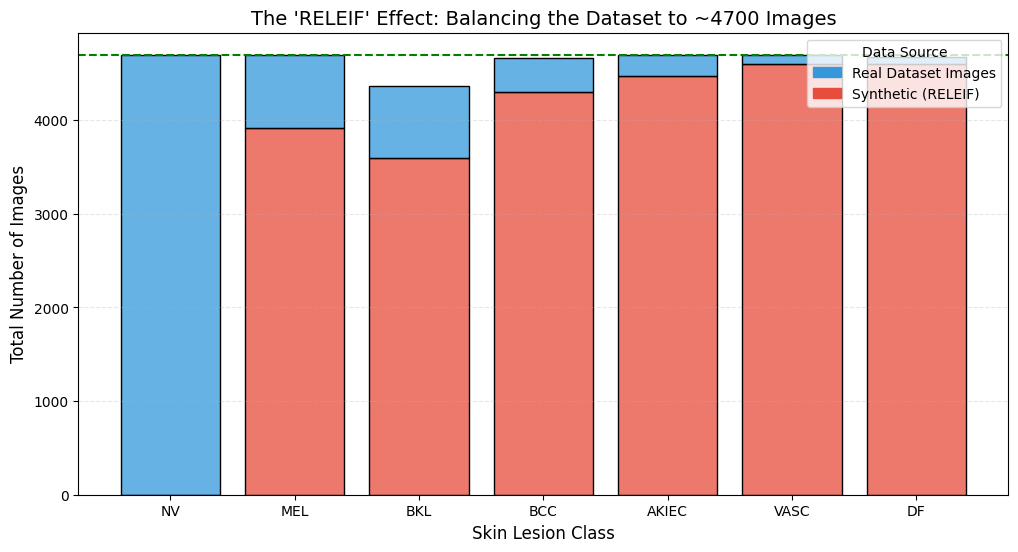

In [7]:
import matplotlib.patches as mpatches

if len(data_for_plot) > 0:
    df_plot = pd.DataFrame(data_for_plot)

    plt.figure(figsize=(12, 6))

    # Create a Stacked Bar Chart
    # We set legend=False because we will build a better custom one below
    sns.histplot(
        data=df_plot,
        x='Class',
        weights='Count',
        hue='Type',
        multiple='stack',
        # Blue for Real, Red for Synthetic
        palette={'Real Images': '#3498db', 'RELEIF Synthetic': '#e74c3c'},
        shrink=0.8,
        legend=False # <--- 2. Disable default legend to avoid conflicts
    )

    # Visual Polish
    plt.title(f"The 'RELEIF' Effect: Balancing the Dataset to ~{target_per_class} Images", fontsize=14)
    plt.ylabel("Total Number of Images", fontsize=12)
    plt.xlabel("Skin Lesion Class", fontsize=12)
    plt.axhline(y=target_per_class, color='green', linestyle='--', label='Balance Target')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # --- 3. THE MANUAL LEGEND FIX ---
    # We explicitly tell Python: "Blue is Real, Red is Synthetic"
    real_patch = mpatches.Patch(color='#3498db', label='Real Dataset Images')
    syn_patch  = mpatches.Patch(color='#e74c3c', label='Synthetic (RELEIF)')

    # Add the custom handles to the legend
    plt.legend(handles=[real_patch, syn_patch], title="Data Source", loc="upper right")

    print("\n🎨 Generating Chart...")
    plt.show()
else:
    print("\n❌ No data to plot. Check your paths!")